In [1]:
import numpy as np
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

df = pd.read_csv('paris-arbres-numerical-2023-09-10.csv')

In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 159388 entries, 0 to 159387
Data columns (total 8 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   domanialite             159388 non-null  int64  
 1   arrondissement          159388 non-null  int64  
 2   libelle_francais        159388 non-null  int64  
 3   genre                   159388 non-null  int64  
 4   espece                  159388 non-null  int64  
 5   circonference_cm        159388 non-null  float64
 6   hauteur_m               159388 non-null  float64
 7   stade_de_developpement  159388 non-null  int64  
dtypes: float64(2), int64(6)
memory usage: 9.7 MB


In [3]:
filename = 'https://raw.githubusercontent.com/OpenClassrooms-Student-Center/8063076-Initiez-vous-au-Machine-Learning/master/data/paris-arbres-numerical-2023-09-10.csv'
data = pd.read_csv(filename)
X = data[['domanialite', 'arrondissement', 'libelle_francais', 'genre', 'espece', 'circonference_cm', 'hauteur_m']]
y = data.stade_de_developpement.values

In [4]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split( X, y, train_size=0.8, random_state=808)

In [5]:
from sklearn.tree import DecisionTreeClassifier

In [6]:
clf = DecisionTreeClassifier(
        max_depth = 3,
    random_state = 808
)
clf.fit(X_train, y_train)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",3
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",808
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at

In [8]:
from sklearn.metrics import roc_auc_score
train_auc = roc_auc_score(y_train, clf.predict_proba(X_train), multi_class='ovr')
test_auc = roc_auc_score(y_test, clf.predict_proba(X_test), multi_class='ovr')
print("train",train_auc)
print("test", test_auc)


train 0.8877114343964885
test 0.8882428014767341


In [10]:
from sklearn.metrics import confusion_matrix
y_train_hat = clf.predict(X_train)
y_test_hat = clf.predict(X_test)
print(confusion_matrix(y_test, y_test_hat))

[[ 5570  1402   300     2]
 [ 1060  3847  2750     8]
 [  211  1481 13328   466]
 [    4     7   565   877]]


In [11]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_test_hat))


              precision    recall  f1-score   support

           1       0.81      0.77      0.79      7274
           2       0.57      0.50      0.53      7665
           3       0.79      0.86      0.82     15486
           4       0.65      0.60      0.63      1453

    accuracy                           0.74     31878
   macro avg       0.70      0.68      0.69     31878
weighted avg       0.73      0.74      0.74     31878



In [12]:
print(clf.score(X_train, y_train))
print(clf.score(X_test, y_test))

0.7409850207826837
0.741012610577828


In [13]:
clf = DecisionTreeClassifier(
    max_depth = None,
    random_state = 808
)
clf.fit(X_train, y_train)
clf.score(X_test, y_test)

0.8060104147060668

In [15]:
clf.score(X_train, y_train)

0.9354560426633205

In [16]:
scores = []
for depth in np.arange(2, 30, 2):
    clf = DecisionTreeClassifier(
        max_depth = depth,
        random_state = 808
    )

    clf.fit(X_train, y_train)

    train_auc = roc_auc_score(y_train, clf.predict_proba(X_train), multi_class='ovr')
    test_auc = roc_auc_score(y_test, clf.predict_proba(X_test), multi_class='ovr')
    scores.append({
        'max_depth': depth,
        'train': train_auc,
        'test': test_auc,
    })

scores = pd.DataFrame(scores)

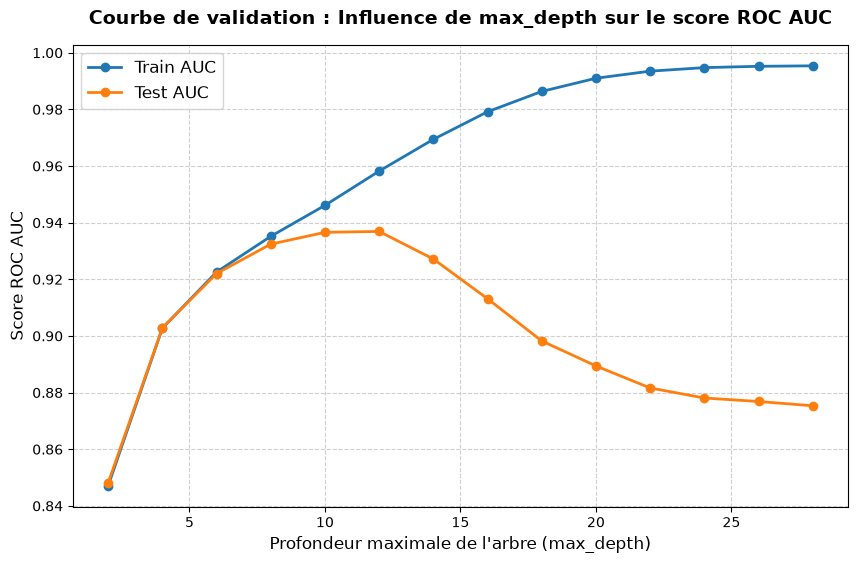

In [17]:
import matplotlib.pyplot as plt

# Création du graphique de manière propre (via subplots)
fig, ax = plt.subplots(figsize=(10, 6))

# Tracé des deux courbes (Train et Test)
ax.plot(scores['max_depth'], scores['train'], label='Train AUC', marker='o', color='#1f77b4', linewidth=2)
ax.plot(scores['max_depth'], scores['test'], label='Test AUC', marker='o', color='#ff7f0e', linewidth=2)

# Personnalisation des titres et des axes
ax.set_title("Courbe de validation : Influence de max_depth sur le score ROC AUC", fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel("Profondeur maximale de l'arbre (max_depth)", fontsize=12)
ax.set_ylabel("Score ROC AUC", fontsize=12)

# Ajout d'une grille en arrière-plan pour mieux lire les valeurs
ax.grid(True, linestyle='--', alpha=0.6)

# Affichage de la légende pour distinguer les deux courbes
ax.legend(fontsize=12, loc='best')